In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot')
%matplotlib inline

import plotly
import plotly.express as px
import plotly.graph_objects as go
#plt.rcParams['figure.figsize']=17,8
import cufflinks as cf
import plotly.offline as pyo
from plotly.offline import init_notebook_mode,plot,iplot

import folium

In [5]:
pyo.init_notebook_mode(connected=True)
cf.go_offline()

In [6]:
df=pd.read_excel(r"Covid cases in India.xlsx")

In [7]:
df

,S. No.,Name of State / UT,Total Confirmed cases (Indian National),Total Confirmed cases ( Foreign National ),Cured,Death
0,1,Andhra Pradesh,12,0,1,0
1,2,Chhattisgarh,6,0,0,0
2,3,Delhi,38,1,6,1
3,4,Gujarat,43,0,0,3
4,5,Haryana,16,14,11,0
5,6,Himachal Pradesh,4,0,0,1
6,7,Karnataka,20,0,3,2
7,8,Kerala,131,7,11,0
8,9,Madhya Pradesh,23,0,0,1
9,10,Maharashtra,144,3,15,4


In [8]:
df.drop(['S. No.'],axis=1,inplace=True)

In [9]:
df

,Name of State / UT,Total Confirmed cases (Indian National),Total Confirmed cases ( Foreign National ),Cured,Death
0,Andhra Pradesh,12,0,1,0
1,Chhattisgarh,6,0,0,0
2,Delhi,38,1,6,1
3,Gujarat,43,0,0,3
4,Haryana,16,14,11,0
5,Himachal Pradesh,4,0,0,1
6,Karnataka,20,0,3,2
7,Kerala,131,7,11,0
8,Madhya Pradesh,23,0,0,1
9,Maharashtra,144,3,15,4


In [10]:
df['Total Cases']=df['Total Confirmed cases (Indian National)']+df['Total Confirmed cases ( Foreign National )']

In [11]:
df

,Name of State / UT,Total Confirmed cases (Indian National),Total Confirmed cases ( Foreign National ),Cured,Death,Total Cases
0,Andhra Pradesh,12,0,1,0,12
1,Chhattisgarh,6,0,0,0,6
2,Delhi,38,1,6,1,39
3,Gujarat,43,0,0,3,43
4,Haryana,16,14,11,0,30
5,Himachal Pradesh,4,0,0,1,4
6,Karnataka,20,0,3,2,20
7,Kerala,131,7,11,0,138
8,Madhya Pradesh,23,0,0,1,23
9,Maharashtra,144,3,15,4,147


In [12]:
total_cases_overall=df['Total Cases'].sum()
print('The total number of cases till now in India is ',total_cases_overall)

The total number of cases till now in India is  729


In [13]:
df['Active Cases']=df['Total Cases']-(df['Death']+df['Cured'])

In [14]:
df

,Name of State / UT,Total Confirmed cases (Indian National),Total Confirmed cases ( Foreign National ),Cured,Death,Total Cases,Active Cases
0,Andhra Pradesh,12,0,1,0,12,11
1,Chhattisgarh,6,0,0,0,6,6
2,Delhi,38,1,6,1,39,32
3,Gujarat,43,0,0,3,43,40
4,Haryana,16,14,11,0,30,19
5,Himachal Pradesh,4,0,0,1,4,3
6,Karnataka,20,0,3,2,20,15
7,Kerala,131,7,11,0,138,127
8,Madhya Pradesh,23,0,0,1,23,22
9,Maharashtra,144,3,15,4,147,128


In [15]:
df.style.background_gradient(cmap='Reds')

,Name of State / UT,Total Confirmed cases (Indian National),Total Confirmed cases ( Foreign National ),Cured,Death,Total Cases,Active Cases
0,Andhra Pradesh,12,0,1,0,12,11
1,Chhattisgarh,6,0,0,0,6,6
2,Delhi,38,1,6,1,39,32
3,Gujarat,43,0,0,3,43,40
4,Haryana,16,14,11,0,30,19
5,Himachal Pradesh,4,0,0,1,4,3
6,Karnataka,20,0,3,2,20,15
7,Kerala,131,7,11,0,138,127
8,Madhya Pradesh,23,0,0,1,23,22
9,Maharashtra,144,3,15,4,147,128


In [16]:
Total_Active_Cases=df.groupby('Name of State / UT')['Total Cases'].sum().sort_values(ascending=False).to_frame()

In [17]:
Total_Active_Cases

,Total Cases
Name of State / UT,
Maharashtra,147
Kerala,138
Telengana,45
Uttar Pradesh,43
Gujarat,43
Rajasthan,43
Delhi,39
Tamil Nadu,35
Haryana,30


In [18]:
Total_Active_Cases.style.background_gradient(cmap='Reds')

,Total Cases
Name of State / UT,
Maharashtra,147
Kerala,138
Telengana,45
Uttar Pradesh,43
Gujarat,43
Rajasthan,43
Delhi,39
Tamil Nadu,35
Haryana,30


In [19]:
################# Graphical Represantaion

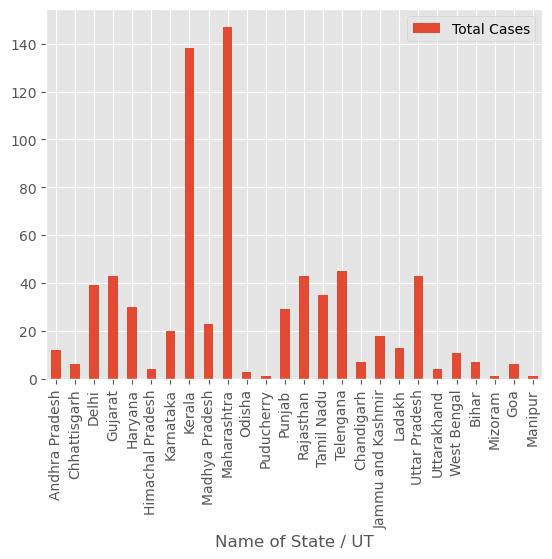

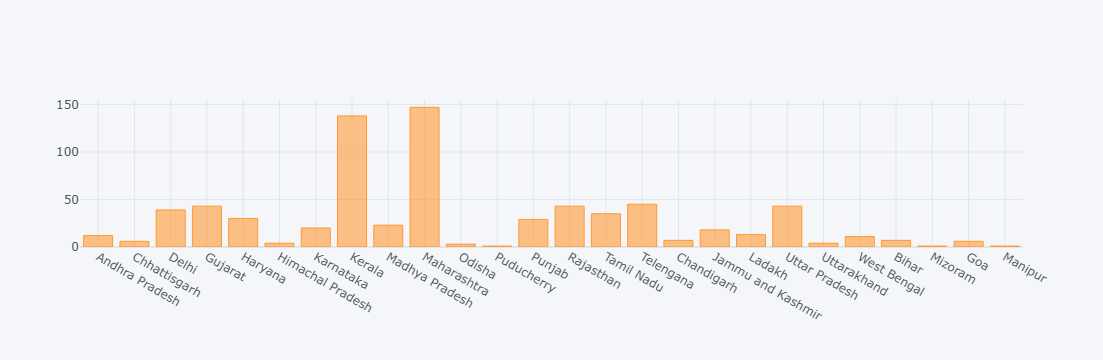

In [20]:
#Pandas vis
df.plot(kind='bar',x='Name of State / UT',y='Total Cases')
plt.show()
#Plotly
df.iplot(kind='bar',x='Name of State / UT',y='Total Cases')

<BarContainer object of 26 artists>

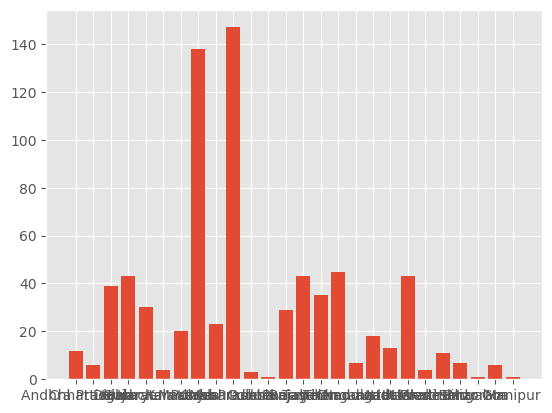

In [21]:
#Matplotlib vis

plt.bar(df['Name of State / UT'],df['Total Cases'])

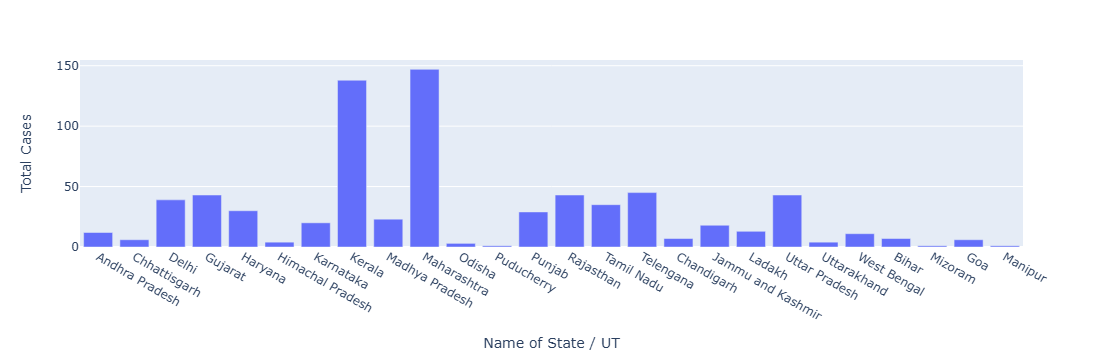

In [22]:
px.bar(df,x='Name of State / UT',y='Total Cases')

<Axes: xlabel='Name of State / UT', ylabel='Total Cases'>

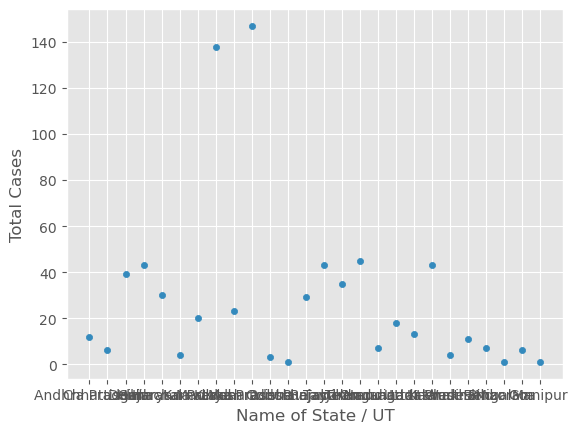

In [23]:
df.plot(kind='scatter',x='Name of State / UT',y='Total Cases')

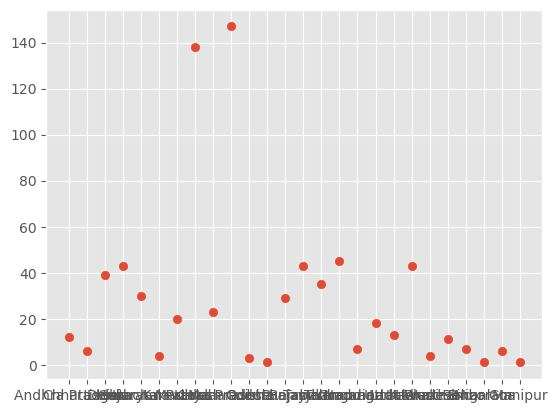

In [45]:
plt.scatter(df['Name of State / UT'],df['Total Cases'])

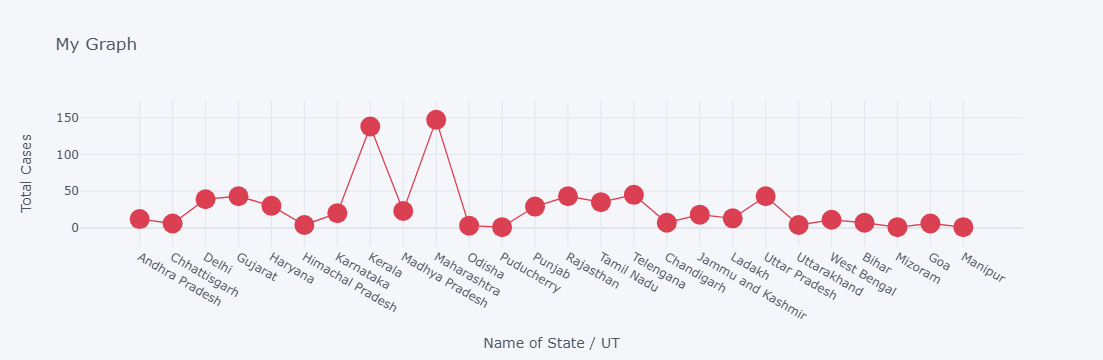

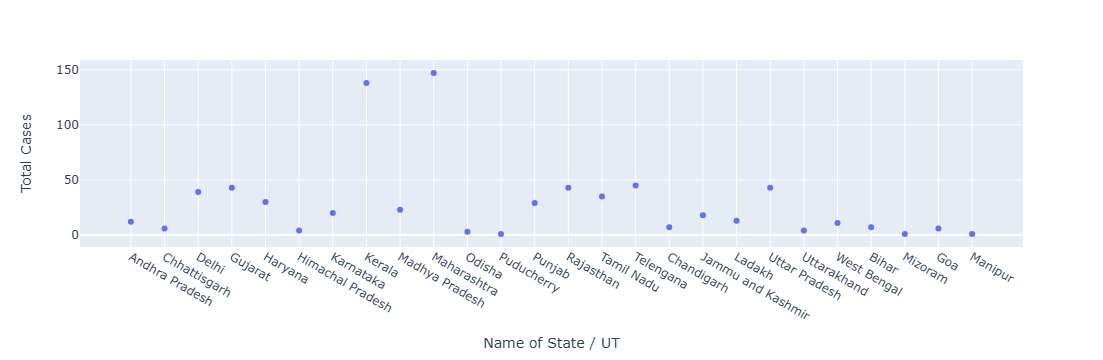

In [49]:
df.iplot(kind='scatter',x='Name of State / UT',y='Total Cases',mode='markers+lines',title='My Graph',xTitle='Name of State / UT',yTitle='Total Cases',colors='red',size=20)
px.scatter(df,x='Name of State / UT',y='Total Cases')

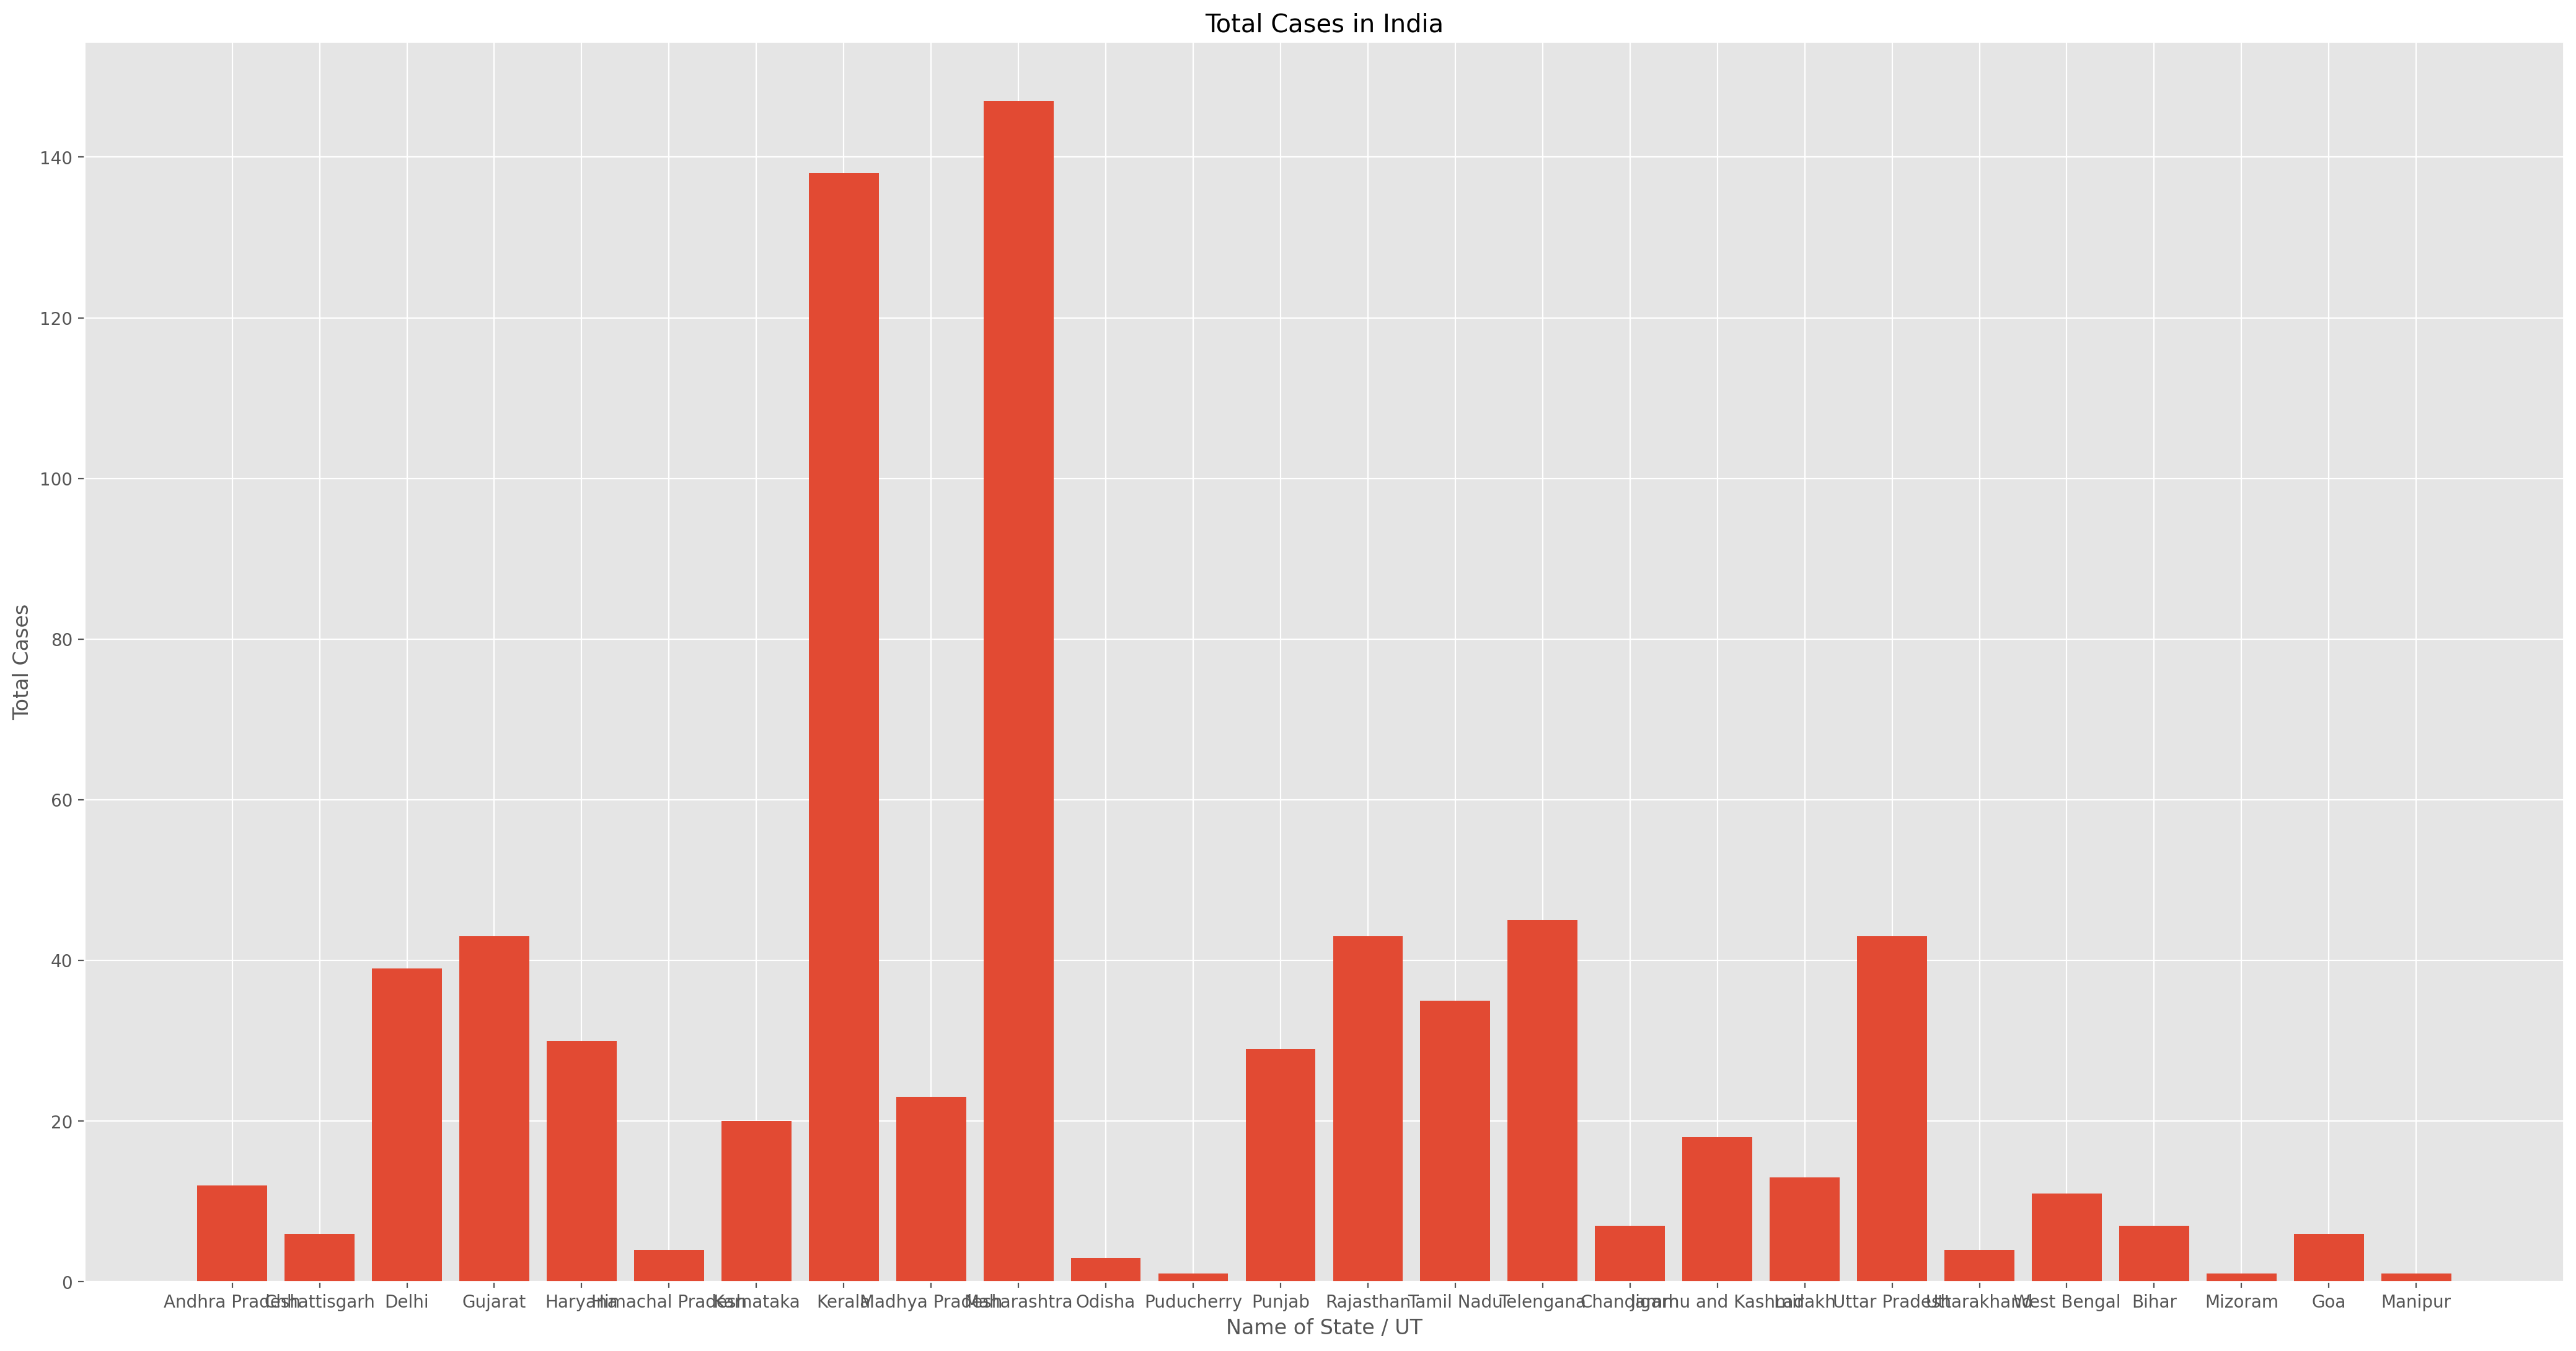

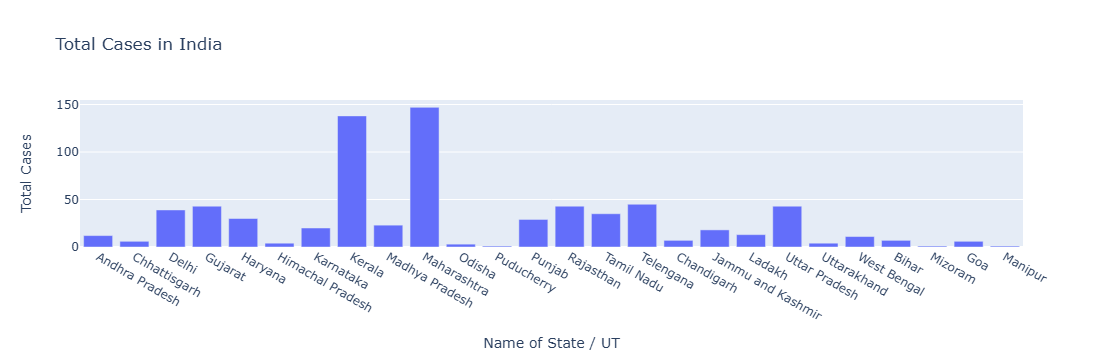

In [51]:
#Matplotlib
fig=plt.figure(figsize=(20,10),dpi=200)
axes=fig.add_axes([0,0,1,1])
axes.bar(df['Name of State / UT'],df['Total Cases'])
axes.set_title("Total Cases in India")
axes.set_xlabel("Name of State / UT")
axes.set_ylabel("Total Cases")
plt.show()

#plotly
fig=go.Figure()
fig.add_trace(go.Bar(x=df['Name of State / UT'],y=df['Total Cases']))
fig.update_layout(title='Total Cases in India',xaxis=dict(title='Name of State / UT'),yaxis=dict(title='Total Cases'))

In [53]:
Indian_Cord=pd.read_excel(r"Indian Coordinates.xlsx")

In [55]:
Indian_Cord

,Name of State / UT,Latitude,Longitude
0,Andaman And Nicobar,11.667026,92.735983
1,Andhra Pradesh,14.750429,78.570026
2,Arunachal Pradesh,27.100399,93.616601
3,Assam,26.749981,94.216667
4,Bihar,25.785414,87.479973
5,Chandigarh,30.719997,76.780006
6,Chhattisgarh,22.090420,82.159987
7,Dadra And Nagar Haveli,20.266578,73.016618
8,Delhi,28.669993,77.230004
9,Goa,15.491997,73.818001


In [57]:
df_full=pd.merge(Indian_Cord,df,on='Name of State / UT')

In [59]:
df_full

,Name of State / UT,Latitude,Longitude,Total Confirmed cases (Indian National),Total Confirmed cases ( Foreign National ),Cured,Death,Total Cases,Active Cases
0,Andhra Pradesh,14.750429,78.570026,12,0,1,0,12,11
1,Delhi,28.669993,77.230004,38,1,6,1,39,32
2,Haryana,28.450006,77.019991,16,14,11,0,30,19
3,Karnataka,12.570381,76.919997,20,0,3,2,20,15
4,Kerala,8.900373,76.569993,131,7,11,0,138,127
5,Maharashtra,19.250232,73.160175,144,3,15,4,147,128
6,Punjab,31.519974,75.980003,29,0,0,1,29,28
7,Rajasthan,26.449999,74.639981,41,2,3,0,43,40
8,Telengana,18.112400,79.019300,34,11,1,0,45,44
9,Tamil Nadu,12.920386,79.150042,32,3,1,1,35,33


In [61]:
map=folium.Map(location=[20,70],zoom_start=4,tiles='Stamenterrain')

In [65]:
for lat,long,value, name in zip(df_full['Latitude'],df_full['Longitude'],df_full['Total Cases'],df_full['Name of State / UT']):
    folium.CircleMarker([lat,long],radius=value*0.8,popup=('<strong>State</strong>: '+str(name).capitalize()+'<br>''<strong>Total Cases</strong>: ' + str(value)+ '<br>'),color='red',fill_color='red',fill_opacity=0.3).add_to(map)

In [67]:
map

In [71]:
# How corona virus is rising Globaly

In [73]:
dbd_India=pd.read_excel(r"per_day_cases.xlsx",parse_dates=True,sheet_name="India")
dbd_Italy=pd.read_excel(r"per_day_cases.xlsx",parse_dates=True,sheet_name="Italy")
dbd_Korea=pd.read_excel(r"per_day_cases.xlsx",parse_dates=True,sheet_name="Korea")
dbd_Wuhan=pd.read_excel(r"per_day_cases.xlsx",parse_dates=True,sheet_name="Wuhan")

In [75]:
dbd_India

,Date,Total Cases,New Cases,Days after surpassing 100 cases
0,2020-01-30,1,1,NaN
1,2020-01-31,1,0,NaN
2,2020-02-01,1,0,NaN
3,2020-02-02,2,1,NaN
4,2020-02-03,3,1,NaN
5,2020-02-04,3,0,NaN
6,2020-02-05,3,0,NaN
7,2020-02-06,3,0,NaN
8,2020-02-07,3,0,NaN
9,2020-02-08,3,0,NaN


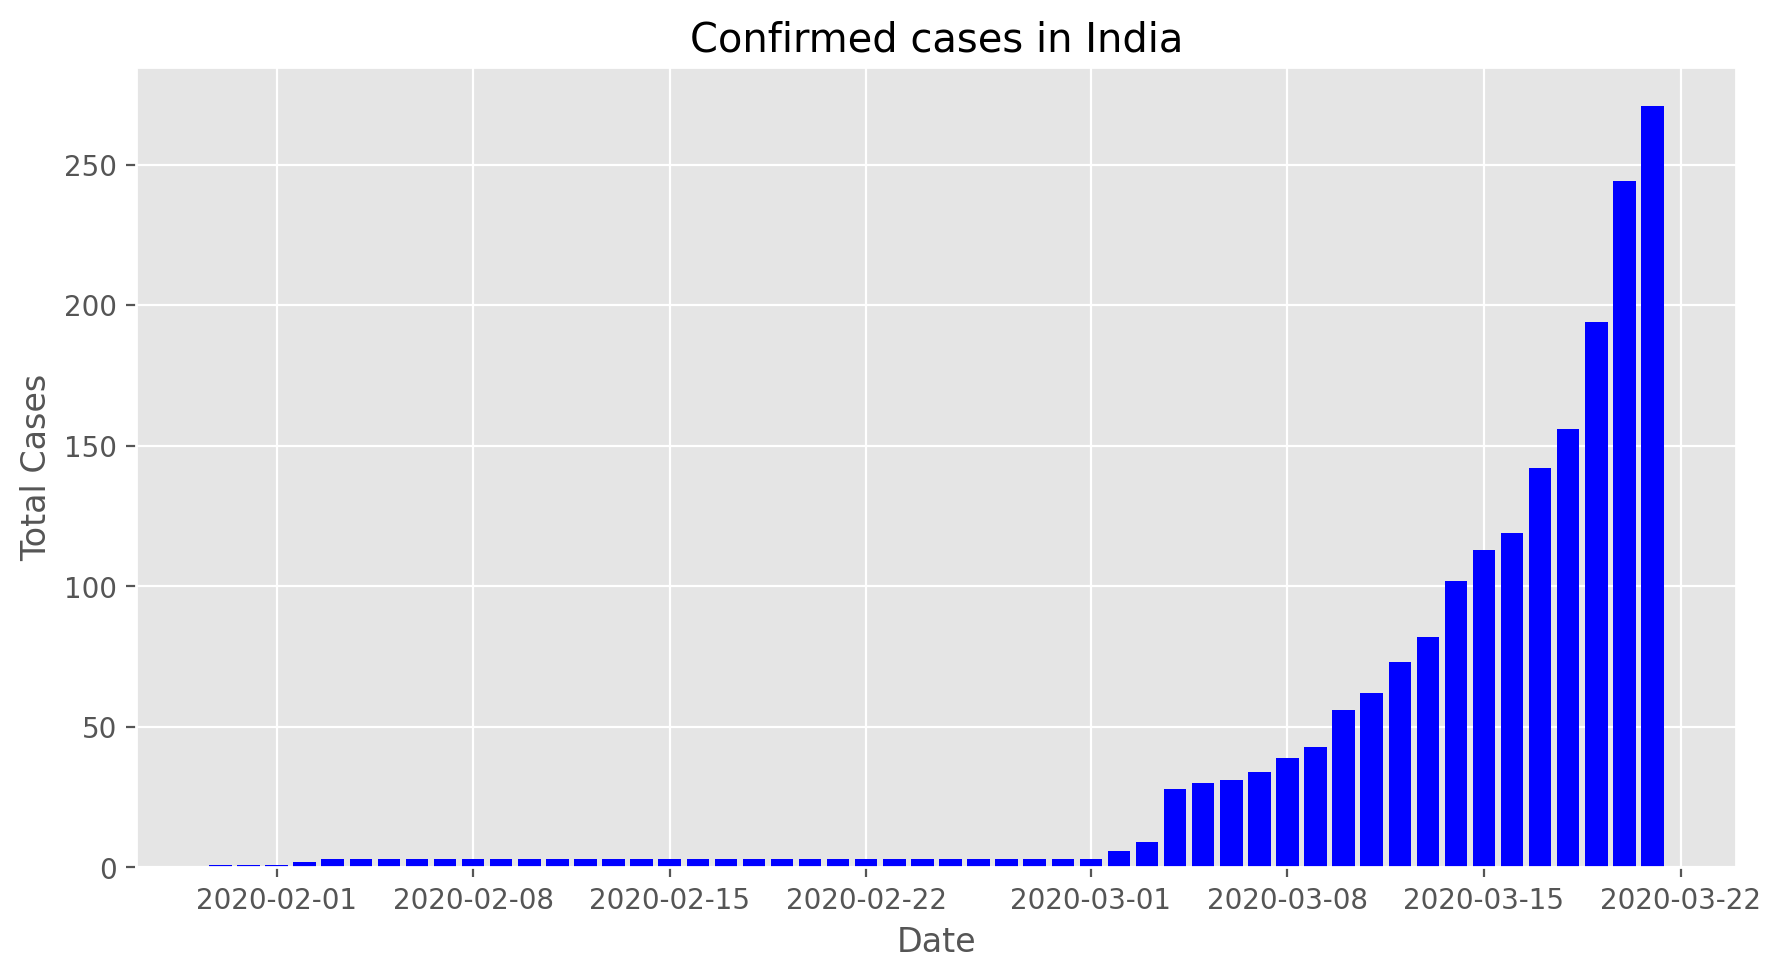

C:\Users\rrsto\anaconda3\Lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



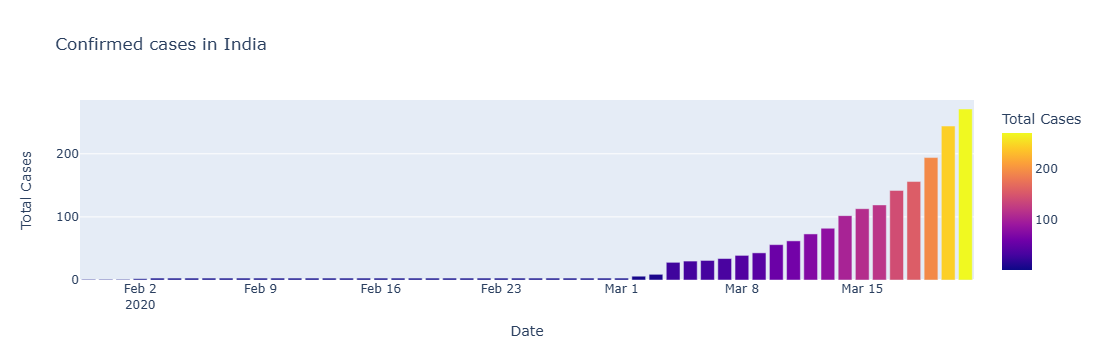

In [77]:
#Matplotlib
fig=plt.figure(figsize=(10,5),dpi=200)
axes=fig.add_axes([0.1,0.1,0.8,0.8])
axes.bar(dbd_India["Date"],dbd_India["Total Cases"],color='blue')
axes.set_xlabel("Date")
axes.set_ylabel("Total Cases")
axes.set_title("Confirmed cases in India")
plt.show()


#plotly Express

fig=px.bar(dbd_India,x="Date",y="Total Cases",color='Total Cases',title='Confirmed cases in India')
fig.show()

C:\Users\rrsto\anaconda3\Lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



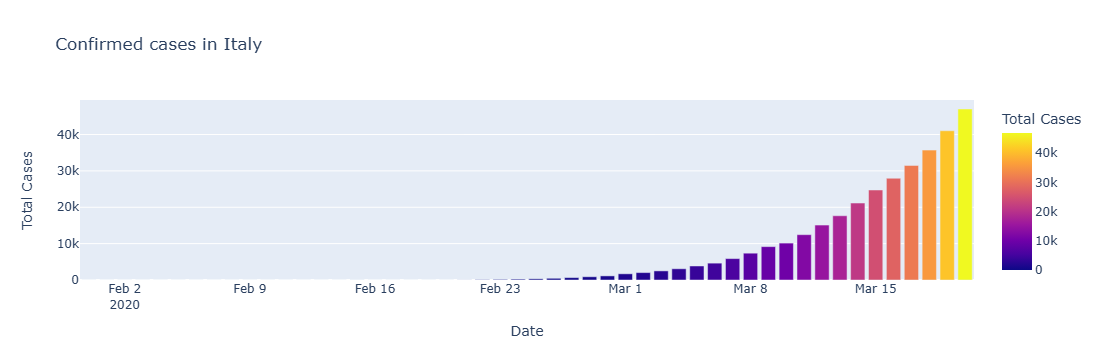

C:\Users\rrsto\anaconda3\Lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



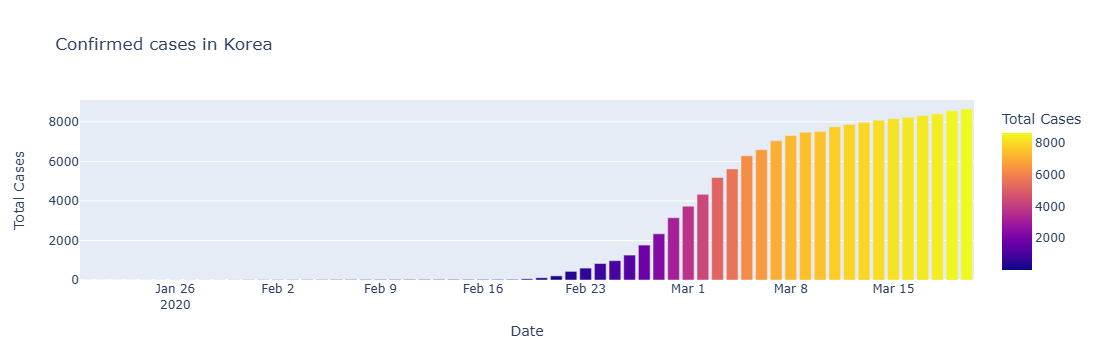

C:\Users\rrsto\anaconda3\Lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



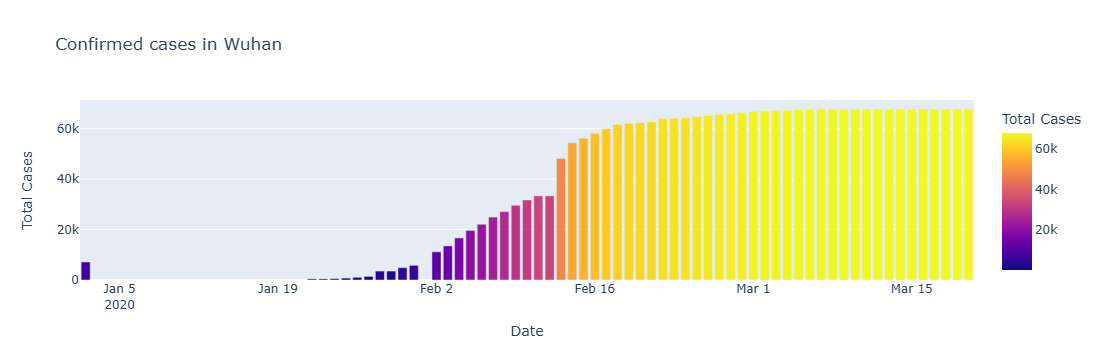

In [79]:
fig=px.bar(dbd_Italy,x="Date",y="Total Cases",color='Total Cases',title='Confirmed cases in Italy')
fig.show()

fig=px.bar(dbd_Korea,x="Date",y="Total Cases",color='Total Cases',title='Confirmed cases in Korea')
fig.show()

fig=px.bar(dbd_Wuhan,x="Date",y="Total Cases",color='Total Cases',title='Confirmed cases in Wuhan')
fig.show()

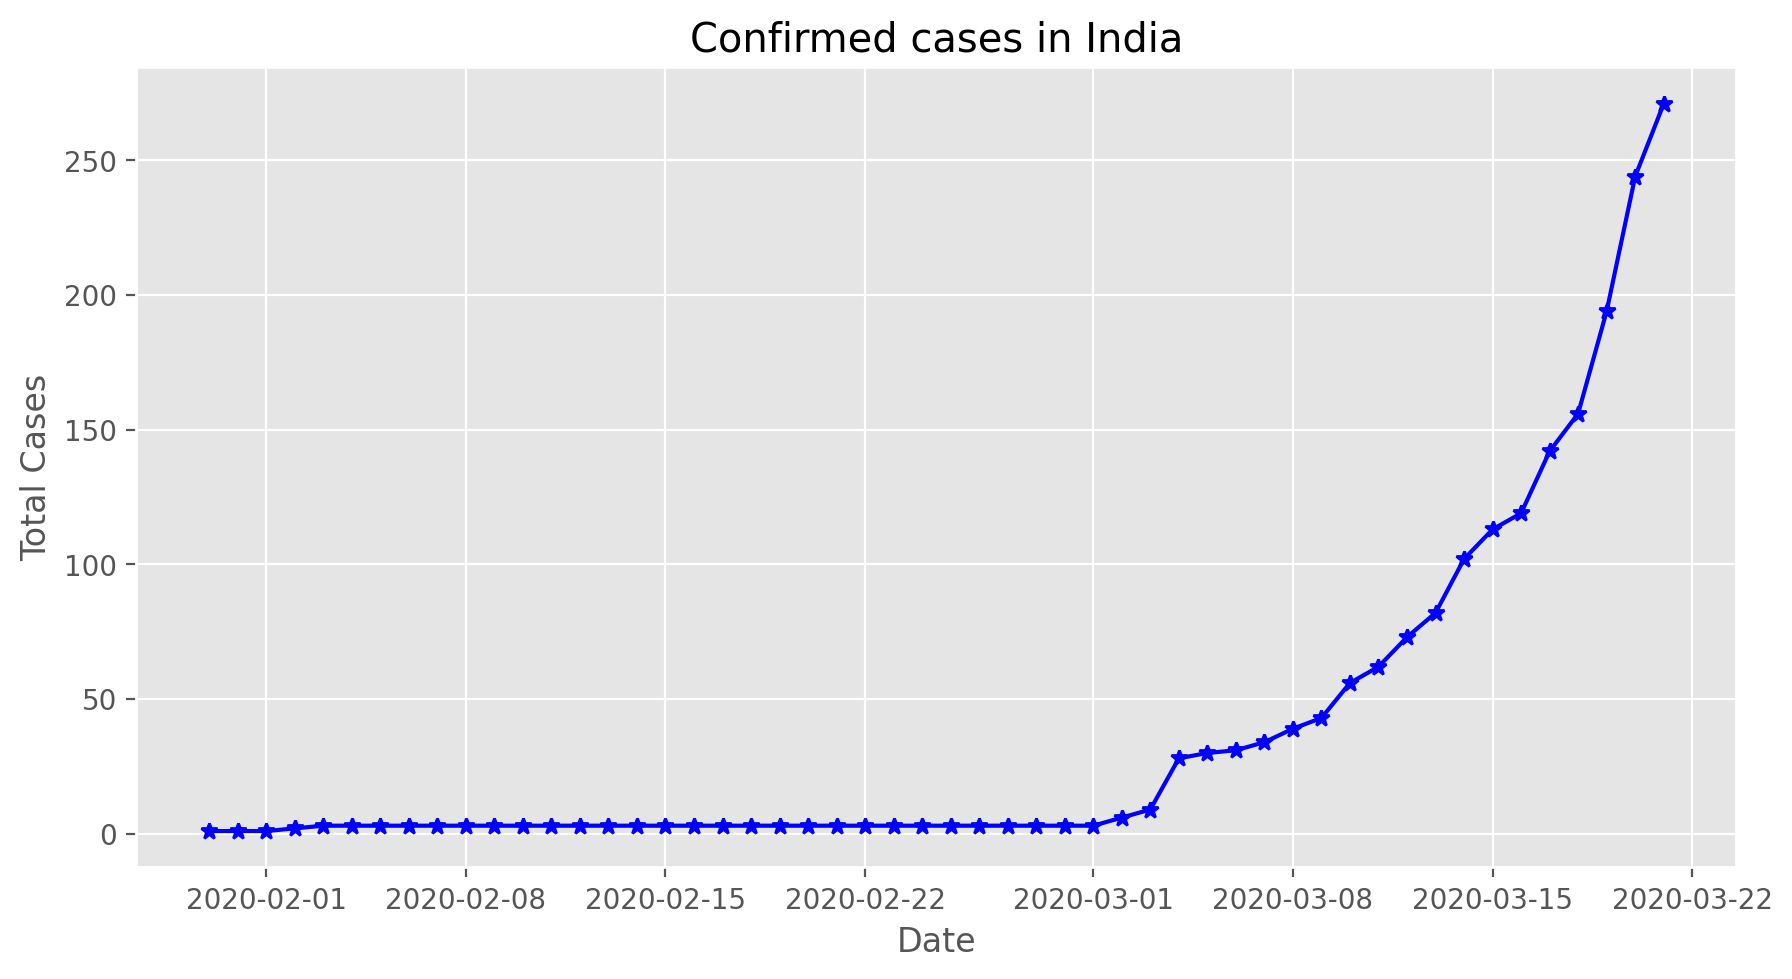

C:\Users\rrsto\anaconda3\Lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



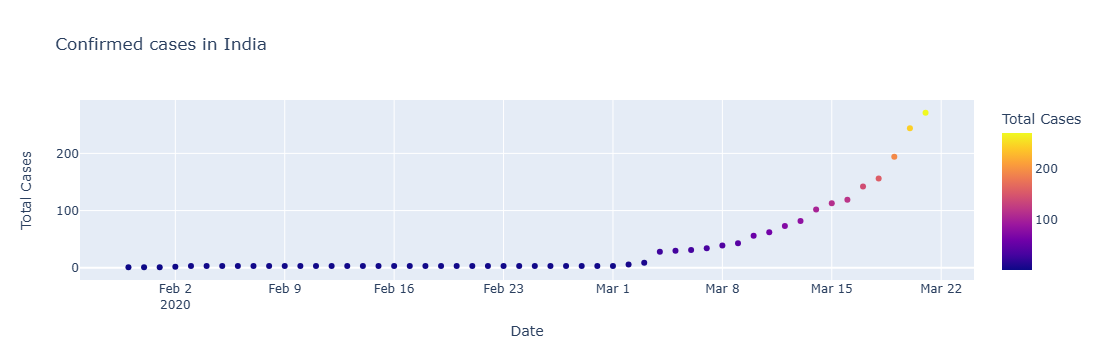

In [81]:
fig=plt.figure(figsize=(10,5),dpi=200)
axes=fig.add_axes([0.1,0.1,0.8,0.8])
axes.plot(dbd_India["Date"],dbd_India["Total Cases"],color='blue',marker='*')
axes.set_xlabel("Date")
axes.set_ylabel("Total Cases")
axes.set_title("Confirmed cases in India")
plt.show()


#plotly Express

fig=px.scatter(dbd_India,x="Date",y="Total Cases",color='Total Cases',title='Confirmed cases in India')
fig.show()

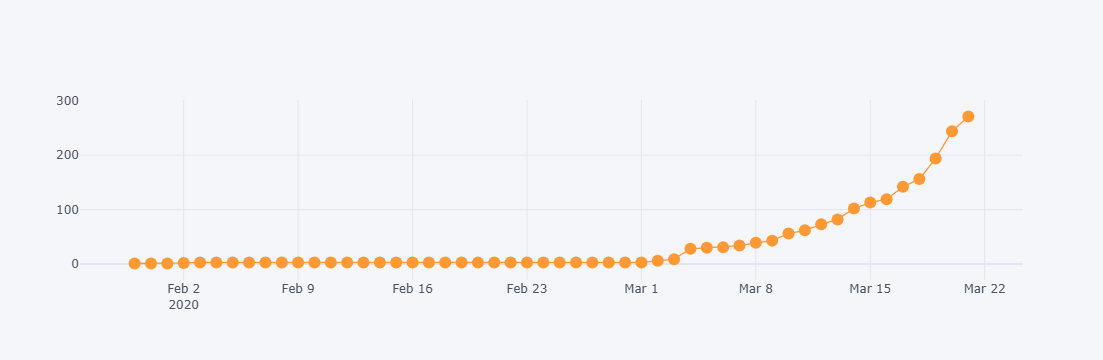

In [85]:
#Plotly
dbd_India.iplot(kind='scatter',x='Date',y='Total Cases',mode='lines+markers')

C:\Users\rrsto\anaconda3\Lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



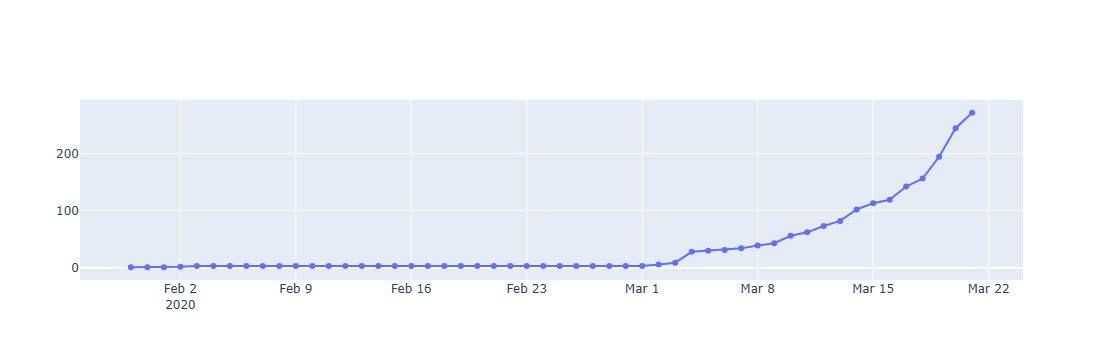

In [87]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=dbd_India['Date'],y=dbd_India['Total Cases'],mode='lines+markers'))

In [91]:
#Subplots using Bar Graph

In [93]:
from plotly.subplots import make_subplots

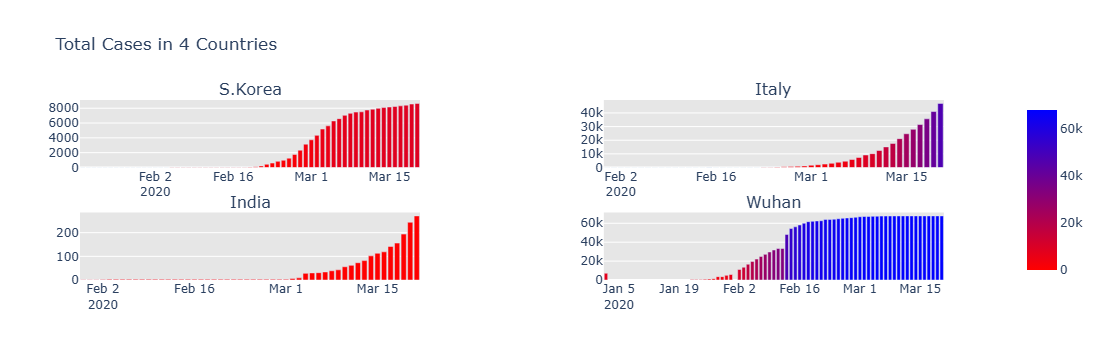

In [95]:
fig=make_subplots(
    rows=2,cols=2,
    specs=[[{"secondary_y":True},{"secondary_y":True}],[{"secondary_y":True},{"secondary_y":True}]],
    subplot_titles=("S.Korea","Italy","India","Wuhan"))

fig.add_trace(go.Bar(x=dbd_Korea['Date'],y=dbd_Korea['Total Cases'],
                    marker=dict(color=dbd_Korea['Total Cases'],coloraxis="coloraxis")),1,1)

fig.add_trace(go.Bar(x=dbd_Italy['Date'],y=dbd_Italy['Total Cases'],
                    marker=dict(color=dbd_Italy['Total Cases'],coloraxis="coloraxis")),1,2)

fig.add_trace(go.Bar(x=dbd_India['Date'],y=dbd_India['Total Cases'],
                    marker=dict(color=dbd_India['Total Cases'],coloraxis="coloraxis")),2,1)

fig.add_trace(go.Bar(x=dbd_Wuhan['Date'],y=dbd_Wuhan['Total Cases'],
                    marker=dict(color=dbd_Wuhan['Total Cases'],coloraxis="coloraxis")),2,2)



fig.update_layout(coloraxis=dict(colorscale='Bluered_r'),showlegend=False,title_text="Total Cases in 4 Countries")

fig.update_layout(plot_bgcolor='rgb(230,230,230)')

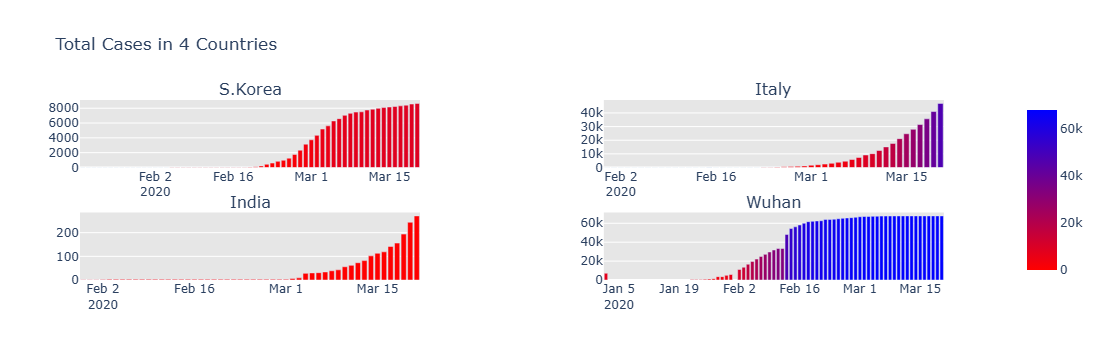

In [97]:
fig=make_subplots(
    rows=2,cols=2,
    specs=[[{"secondary_y":True},{"secondary_y":True}],[{"secondary_y":True},{"secondary_y":True}]],
    subplot_titles=("S.Korea","Italy","India","Wuhan"))

fig.add_trace(go.Bar(x=dbd_Korea['Date'],y=dbd_Korea['Total Cases'],
                    marker=dict(color=dbd_Korea['Total Cases'],coloraxis="coloraxis")),1,1)

fig.add_trace(go.Bar(x=dbd_Italy['Date'],y=dbd_Italy['Total Cases'],
                    marker=dict(color=dbd_Italy['Total Cases'],coloraxis="coloraxis")),1,2)

fig.add_trace(go.Bar(x=dbd_India['Date'],y=dbd_India['Total Cases'],
                    marker=dict(color=dbd_India['Total Cases'],coloraxis="coloraxis")),2,1)

fig.add_trace(go.Bar(x=dbd_Wuhan['Date'],y=dbd_Wuhan['Total Cases'],
                    marker=dict(color=dbd_Wuhan['Total Cases'],coloraxis="coloraxis")),2,2)



fig.update_layout(coloraxis=dict(colorscale='Bluered_r'),showlegend=False,title_text="Total Cases in 4 Countries")

fig.update_layout(plot_bgcolor='rgb(230,230,230)')

In [101]:
#World Coronavirus

In [103]:
df=pd.read_csv('covid_19_data.csv',parse_dates=['Last Update'])

In [107]:
df.head()

,SNo,Date,Province/State,Country,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0


In [105]:
df.rename(columns={'ObservationDate':'Date','Country/Region':'Country'},inplace=True)
df

,SNo,Date,Province/State,Country,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
5885,5886,03/15/2020,Gibraltar,UK,2020-03-14T16:33:03,1.0,0.0,1.0
5886,5887,03/15/2020,NaN,Uzbekistan,2020-03-15T18:20:19,1.0,0.0,0.0
5887,5888,03/15/2020,Diamond Princess cruise ship,Australia,2020-03-14T02:33:04,0.0,0.0,0.0
5888,5889,03/15/2020,West Virginia,US,2020-03-10T02:33:04,0.0,0.0,0.0


In [109]:
df.query('Country=="UK"')

,SNo,Date,Province/State,Country,Last Update,Confirmed,Deaths,Recovered
481,482,01/31/2020,NaN,UK,1/31/2020 23:59,2.0,0.0,0.0
541,542,02/01/2020,NaN,UK,2/1/2020 1:52,2.0,0.0,0.0
611,612,02/02/2020,NaN,UK,2020-02-01T01:52:40,2.0,0.0,0.0
678,679,02/03/2020,NaN,UK,2020-02-01T01:52:40,2.0,0.0,0.0
746,747,02/04/2020,NaN,UK,2020-02-01T01:52:40,2.0,0.0,0.0
817,818,02/05/2020,NaN,UK,2020-02-01T01:52:40,2.0,0.0,0.0
888,889,02/06/2020,NaN,UK,2020-02-01T01:52:40,2.0,0.0,0.0
957,958,02/07/2020,NaN,UK,2020-02-07T18:33:02,3.0,0.0,0.0
1029,1030,02/08/2020,NaN,UK,2020-02-07T18:33:02,3.0,0.0,0.0
1101,1102,02/09/2020,NaN,UK,2020-02-07T18:33:02,3.0,0.0,0.0


In [111]:
df.groupby('Date').sum()

,SNo,Province/State,Country,Last Update,Confirmed,Deaths,Recovered
Date,,,,,,,
01/22/2020,741,AnhuiBeijingChongqingFujianGansuGuangdongGuang...,Mainland ChinaMainland ChinaMainland ChinaMain...,1/22/2020 17:001/22/2020 17:001/22/2020 17:001...,555.0,17.0,28.0
01/23/2020,2829,AnhuiBeijingChongqingFujianGansuGuangdongGuang...,Mainland ChinaMainland ChinaMainland ChinaMain...,1/23/20 17:001/23/20 17:001/23/20 17:001/23/20...,653.0,18.0,30.0
01/24/2020,4305,HubeiGuangdongZhejiangBeijingChongqingHunanGua...,Mainland ChinaMainland ChinaMainland ChinaMain...,1/24/20 17:001/24/20 17:001/24/20 17:001/24/20...,941.0,26.0,36.0
01/25/2020,6490,HubeiGuangdongZhejiangChongqingHunanBeijingAnh...,Mainland ChinaMainland ChinaMainland ChinaMain...,1/25/20 17:001/25/20 17:001/25/20 17:001/25/20...,1438.0,42.0,39.0
01/26/2020,9071,HubeiGuangdongZhejiangHenanChongqingHunanBeiji...,Mainland ChinaMainland ChinaMainland ChinaMain...,1/26/20 16:001/26/20 16:001/26/20 16:001/26/20...,2118.0,56.0,52.0
01/27/2020,12342,HubeiGuangdongZhejiangHenanChongqingHunanBeiji...,Mainland ChinaMainland ChinaMainland ChinaMain...,1/27/20 23:591/27/20 23:591/27/20 23:591/27/20...,2927.0,82.0,61.0
01/28/2020,15262,HubeiGuangdongZhejiangHenanHunanChongqingJiang...,Mainland ChinaMainland ChinaMainland ChinaMain...,1/28/20 23:001/28/20 23:001/28/20 23:001/28/20...,5578.0,131.0,107.0
01/29/2020,18711,HubeiZhejiangGuangdongHunanHenanAnhuiChongqing...,Mainland ChinaMainland ChinaMainland ChinaMain...,1/29/20 19:301/29/20 19:301/29/20 19:301/29/20...,6165.0,133.0,126.0
01/30/2020,23345,HubeiZhejiangGuangdongHenanHunanAnhuiChongqing...,Mainland ChinaMainland ChinaMainland ChinaMain...,1/30/20 16:001/30/20 16:001/30/20 16:001/30/20...,8235.0,171.0,143.0


In [113]:
confirmed=df.groupby('Date').sum()['Confirmed'].reset_index()
death=df.groupby('Date').sum()['Deaths'].reset_index()
rec=df.groupby('Date').sum()['Recovered'].reset_index()

In [123]:
print('confirmed')
print(confirmed)

confirmed
          Date  Confirmed
0   01/22/2020      555.0
1   01/23/2020      653.0
2   01/24/2020      941.0
3   01/25/2020     1438.0
4   01/26/2020     2118.0
5   01/27/2020     2927.0
6   01/28/2020     5578.0
7   01/29/2020     6165.0
8   01/30/2020     8235.0
9   01/31/2020     9925.0
10  02/01/2020    12038.0
11  02/02/2020    16787.0
12  02/03/2020    19881.0
13  02/04/2020    23892.0
14  02/05/2020    27636.0
15  02/06/2020    30818.0
16  02/07/2020    34392.0
17  02/08/2020    37121.0
18  02/09/2020    40151.0
19  02/10/2020    42763.0
20  02/11/2020    44803.0
21  02/12/2020    45222.0
22  02/13/2020    60370.0
23  02/14/2020    66887.0
24  02/15/2020    69032.0
25  02/16/2020    71226.0
26  02/17/2020    73260.0
27  02/18/2020    75138.0
28  02/19/2020    75641.0
29  02/20/2020    76199.0
30  02/21/2020    76843.0
31  02/22/2020    78599.0
32  02/23/2020    78985.0
33  02/24/2020    79570.0
34  02/25/2020    80415.0
35  02/26/2020    81397.0
36  02/27/2020    82756.0
37

In [125]:
print('death')
print(death)

death
          Date  Deaths
0   01/22/2020    17.0
1   01/23/2020    18.0
2   01/24/2020    26.0
3   01/25/2020    42.0
4   01/26/2020    56.0
5   01/27/2020    82.0
6   01/28/2020   131.0
7   01/29/2020   133.0
8   01/30/2020   171.0
9   01/31/2020   213.0
10  02/01/2020   259.0
11  02/02/2020   362.0
12  02/03/2020   426.0
13  02/04/2020   492.0
14  02/05/2020   564.0
15  02/06/2020   634.0
16  02/07/2020   719.0
17  02/08/2020   806.0
18  02/09/2020   906.0
19  02/10/2020  1013.0
20  02/11/2020  1113.0
21  02/12/2020  1118.0
22  02/13/2020  1371.0
23  02/14/2020  1523.0
24  02/15/2020  1666.0
25  02/16/2020  1770.0
26  02/17/2020  1868.0
27  02/18/2020  2007.0
28  02/19/2020  2122.0
29  02/20/2020  2247.0
30  02/21/2020  2251.0
31  02/22/2020  2458.0
32  02/23/2020  2469.0
33  02/24/2020  2629.0
34  02/25/2020  2708.0
35  02/26/2020  2770.0
36  02/27/2020  2814.0
37  02/28/2020  2872.0
38  02/29/2020  2941.0
39  03/01/2020  2996.0
40  03/02/2020  3085.0
41  03/03/2020  3160.0
42  0

In [127]:
print('rec')
print(rec)

rec
          Date  Recovered
0   01/22/2020       28.0
1   01/23/2020       30.0
2   01/24/2020       36.0
3   01/25/2020       39.0
4   01/26/2020       52.0
5   01/27/2020       61.0
6   01/28/2020      107.0
7   01/29/2020      126.0
8   01/30/2020      143.0
9   01/31/2020      222.0
10  02/01/2020      284.0
11  02/02/2020      472.0
12  02/03/2020      623.0
13  02/04/2020      852.0
14  02/05/2020     1124.0
15  02/06/2020     1487.0
16  02/07/2020     2011.0
17  02/08/2020     2616.0
18  02/09/2020     3244.0
19  02/10/2020     3946.0
20  02/11/2020     4683.0
21  02/12/2020     5150.0
22  02/13/2020     6295.0
23  02/14/2020     8058.0
24  02/15/2020     9395.0
25  02/16/2020    10865.0
26  02/17/2020    12583.0
27  02/18/2020    14352.0
28  02/19/2020    16121.0
29  02/20/2020    18177.0
30  02/21/2020    18890.0
31  02/22/2020    22886.0
32  02/23/2020    23394.0
33  02/24/2020    25227.0
34  02/25/2020    27905.0
35  02/26/2020    30384.0
36  02/27/2020    33277.0
37  02/2

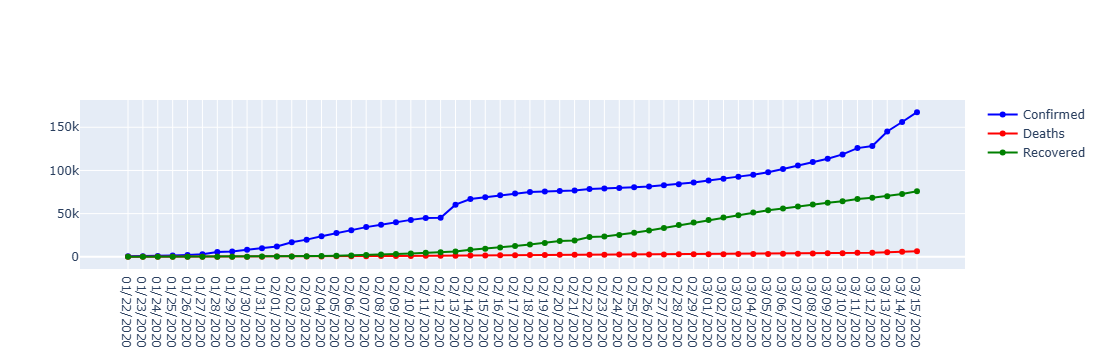

In [129]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=confirmed['Date'],y=confirmed['Confirmed'],mode='lines+markers',name='Confirmed',line=dict(color='blue',width=2)))

fig.add_trace(go.Scatter(x=death['Date'],y=death['Deaths'],mode='lines+markers',name='Deaths',line=dict(color='red',width=2)))
fig.add_trace(go.Scatter(x=rec['Date'],y=rec['Recovered'],mode='lines+markers',name='Recovered',line=dict(color='green',width=2)))

In [134]:
df_confirmed=pd.read_csv(r'time_series_covid_19_confirmed.csv')

In [136]:
df_confirmed.rename(columns={'Country/Region':'Country'},inplace=True)

In [138]:
df_latlong=pd.merge(df,df_confirmed,on=['Country','Province/State'])
df_latlong

,SNo,Date,Province/State,Country,Last Update,Confirmed,Deaths,Recovered,Lat,Long,...,3/5/20,3/6/20,3/7/20,3/8/20,3/9/20,3/10/20,3/11/20,3/12/20,3/13/20,3/14/20
0,32,01/22/2020,Washington,US,1/22/2020 17:00,1.0,0.0,0.0,47.4009,-121.4905,...,0,0,0,0,0,267,366,442,568,572
1,70,01/23/2020,Washington,US,1/23/20 17:00,1.0,0.0,0.0,47.4009,-121.4905,...,0,0,0,0,0,267,366,442,568,572
2,118,01/24/2020,Washington,US,1/24/20 17:00,1.0,0.0,0.0,47.4009,-121.4905,...,0,0,0,0,0,267,366,442,568,572
3,159,01/25/2020,Washington,US,1/25/20 17:00,1.0,0.0,0.0,47.4009,-121.4905,...,0,0,0,0,0,267,366,442,568,572
4,203,01/26/2020,Washington,US,1/26/20 16:00,1.0,0.0,0.0,47.4009,-121.4905,...,0,0,0,0,0,267,366,442,568,572
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3288,5879,03/15/2020,NaN,Saint Vincent and the Grenadines,2020-03-14T16:33:03,1.0,0.0,0.0,12.9843,-61.2872,...,0,0,0,0,0,0,0,0,0,1
3289,5625,03/14/2020,NaN,Suriname,2020-03-14T16:33:03,1.0,0.0,0.0,3.9193,-56.0278,...,0,0,0,0,0,0,0,0,0,1
3290,5881,03/15/2020,NaN,Suriname,2020-03-14T16:33:03,1.0,0.0,0.0,3.9193,-56.0278,...,0,0,0,0,0,0,0,0,0,1
3291,5628,03/14/2020,"Virgin Islands, U.S.",US,2020-03-14T16:15:18,1.0,0.0,0.0,18.3358,-64.8963,...,0,0,0,0,0,0,0,0,0,1


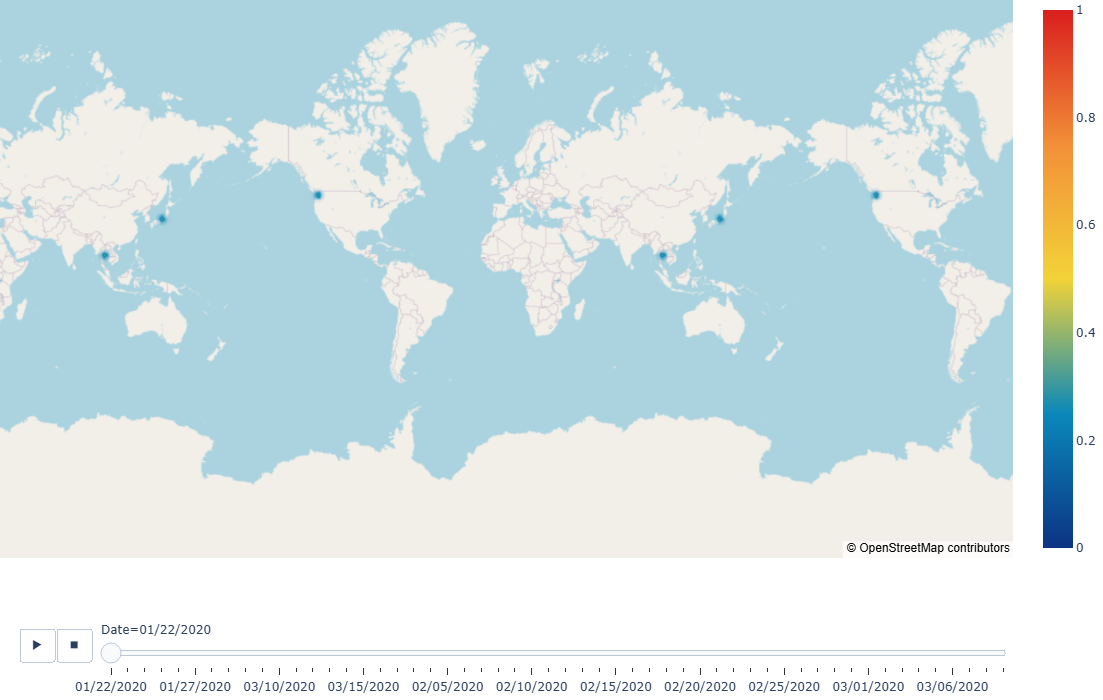

In [140]:
fig=px.density_mapbox(df_latlong,lat="Lat",lon="Long",hover_name="Province/State",hover_data=["Confirmed","Deaths","Recovered"],animation_frame="Date",color_continuous_scale="Portland",radius=7,zoom=0,height=700)
fig.update_layout(title='Worldwide Corona Virus Cases')
fig.update_layout(mapbox_style="open-street-map",mapbox_center_lon=0)
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})